In [1]:
pwd

'/home/jovyan/dev/dea-notebooks/Claire/CoastInsights'

In [2]:
import geopandas as gpd

import fiona

import matplotlib.pyplot as plt
import pandas as pd

# Load Coastal Compartments to regionalise the Smartline gap analysis

In [ ]:
#List all layers in the target geodatabase

layers = fiona.listlayers("/gdata1/data/coastal_compartments/CoastalCompartments_v3.gdb")

print (layers)

In [ ]:
# divisions = gpd.read_file("/gdata1/data/coastal_compartments/CoastalCompartments_v3.gdb", layer='Divisions')
Realms = gpd.read_file("/gdata1/data/coastal_compartments/CoastalCompartments_v3.gdb", layer='Realms')

In [ ]:
Realms

In [ ]:
Realms.plot()

In [ ]:
# Combine sedimentary compartments realms layer into single coastal polygon of buffered Australian coastline
coastalzone = Realms.union_all()
coastalzone

# Load Smartline

In [3]:
layers = fiona.listlayers("/gdata1/data/smartline/Smartline.gpkg")

print (layers)

['Smartline100K']


In [4]:
smartline = gpd.read_file("/gdata1/data/smartline/Smartline.gpkg")

In [ ]:
smartline.head()

In [ ]:
# smartline.columns

# Read in the GEODATA_COAST_100k dataset.
# Create state bounding boxes, removing overlaps, to ensure that offshore areas are included in state boundaries.
# Warning - this used a non-authoritative offshore boundary. This dataset is intended to capture coasts not deep offshore areas!

In [ ]:
boundaries = gpd.read_file('~/gdata1/data/boundaries/GEODATA_COAST_100K/australia/cstauscd_r.shp')

In [ ]:
bbox_gdf = boundaries.copy()
bbox_gdf['geometry'] = boundaries.envelope

fig, ax = plt.subplots(figsize=(10, 8))
boundaries.plot(column='STATE_CODE', ax=ax, edgecolor='black', facecolor='lightgrey', alpha=0.5)
bbox_gdf.boundary.plot(ax=ax, color='red', linewidth=1)

# for idx, row in boundaries.iterrows():
#     minx, miny, maxx, maxy = row.geometry.bounds
#     ax.text(maxx, maxy, row['STATE_CODE'], fontsize=8, color='red')  # swap column name as needed


ax.set_axis_off()
plt.show()

In [ ]:
sorted_bbox = bbox_gdf.sort_values('AREA', ascending=False)
sortedclipped_bbox = sorted_bbox.loc[sorted_bbox['AREA'].where(sorted_bbox['AREA']>1).dropna().index]
sortedclipped_bbox


# smartline.loc[unclass.dropna().index]

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sortedclipped_bbox.boundary.plot(ax=ax, color='red', linewidth=1)
boundaries.plot(column='STATE_CODE', ax=ax, edgecolor='black', facecolor='lightgrey', alpha=0.5)
# sortedclipped_bbox.boundary.where(sortedclipped_bbox['AREA']==18.275141).plot(edgecolor='black', linewidth=2)

for idx, row in sortedclipped_bbox.iterrows():
    minx, miny, maxx, maxy = row.geometry.bounds
    ax.text(maxx, maxy, idx, fontsize=8, color='red')  # swap column name as needed

In [ ]:
# merge qld terrestrial and offshore polygon areas (offshore is a bbox of the terrestrial area. It is NOT authoritative)
qld = sortedclipped_bbox.loc[[0,418]]
qld = qld.geometry.union_all()
qld = gpd.GeoDataFrame(geometry=[qld], crs=sortedclipped_bbox.crs)
# Remove overlapping state offshore areas
qld = qld.difference(sortedclipped_bbox.loc[[6349]], align=False)
qld = qld.difference(sortedclipped_bbox.loc[[6088]], align=False)
qld = qld.difference(boundaries.where(boundaries['STATE_CODE']==3).union_all(), align=False)
qld = qld.union(boundaries.where(boundaries['STATE_CODE']==5).union_all())

In [ ]:
nsw = sortedclipped_bbox.loc[[6349, 6350]]
nsw = nsw.geometry.union_all()
nsw = gpd.GeoDataFrame(geometry=[nsw], crs=sortedclipped_bbox.crs)
# Tidy up using terrestrial state boundaries
nsw = nsw.difference(boundaries.where(boundaries['STATE_CODE']==5).union_all(), align=False)
nsw = nsw.difference(boundaries.where(boundaries['STATE_CODE']==8).union_all(), align=False)
nsw = nsw.difference(boundaries.where(boundaries['STATE_CODE']==6).union_all(), align=False)

In [ ]:
tas = sortedclipped_bbox.loc[[7694]]

In [ ]:
vic = sortedclipped_bbox.loc[[6858, 7492]]
vic = vic.geometry.union_all()
vic = gpd.GeoDataFrame(geometry=[vic], crs=sortedclipped_bbox.crs)
# Tidy up using terrestrial boundaries
vic = vic.difference(boundaries.where(boundaries['STATE_CODE']==3).union_all(), align=False)
vic = vic.difference(boundaries.where(boundaries['STATE_CODE']==2).union_all(), align=False)
vic = vic.difference(boundaries.where(boundaries['STATE_CODE']==1).union_all(), align=False)
vic = vic.difference(nsw)

In [ ]:
sa = sortedclipped_bbox.loc[[6088, 6498]]
sa = sa.geometry.union_all()
sa = gpd.GeoDataFrame(geometry=[sa], crs=sortedclipped_bbox.crs)

In [ ]:
nt= sortedclipped_bbox.loc[[545, 473]]
nt = nt.geometry.union_all()
nt = gpd.GeoDataFrame(geometry=[nt], crs=sortedclipped_bbox.crs)

In [ ]:
wa= sortedclipped_bbox.loc[[1409,4478,1265]]
wa = wa.geometry.union_all()
wa = gpd.GeoDataFrame(geometry=[wa], crs=sortedclipped_bbox.crs)

In [ ]:
# Combine into single dataframe

state_coast_boundaries = pd.concat([wa,nt,sa,tas,vic,nsw,qld], ignore_index=True)
state_coast_boundaries = gpd.GeoDataFrame(state_coast_boundaries, crs=wa.crs)

# Format the dataframe
state_coast_boundaries['geometry'] = state_coast_boundaries['geometry'].fillna(state_coast_boundaries[0])
state_coast_boundaries = state_coast_boundaries[['geometry']]

state_coast_boundaries

In [ ]:
labels = ['wa','nt','sa','tas','vic','nsw','qld']
state_coast_boundaries['name'] = labels
state_coast_boundaries

In [ ]:
state_coast_boundaries.plot(column='name', legend=True)

In [ ]:
# Export to geojson
# state_coast_boundaries.to_file('~/gdata1/data/boundaries/GEODATA_COAST_100K/state_coast_boundaries', driver='GeoJSON')

<Axes: >

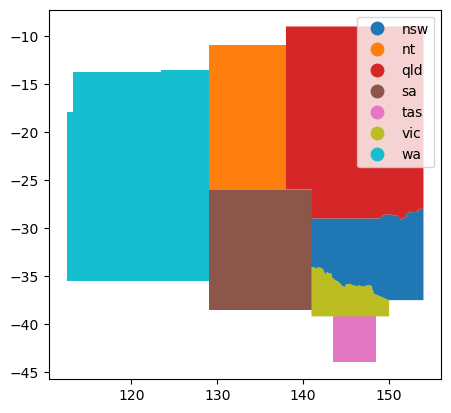

In [5]:
# Load boundaries

state_coast_boundaries = gpd.read_file('~/gdata1/data/boundaries/GEODATA_COAST_100K/state_coast_boundaries')
state_coast_boundaries.plot(column='name', legend=True)

In [ ]:
state_coast_boundaries.plot(edgecolor='black',facecolor='none')

# nt.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2, zorder=2)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
# sortedclipped_bbox.boundary.loc[[1409,4478,1265]].plot(ax=ax, color='red', linewidth=1)
# boundaries.where(boundaries['STATE_CODE']==6).plot(column='STATE_CODE', ax=ax, edgecolor='black', facecolor='lightgrey', alpha=0.5, zorder=10)
boundaries.plot(column='STATE_CODE', ax=ax, edgecolor='black', facecolor='lightgrey', alpha=0.2)
state_coast_boundaries.plot(ax=ax, edgecolor='black',facecolor='none',zorder=2)

# # sortedclipped_bbox.boundary.loc[[545, 473]].plot(ax=ax, edgecolor='black', linewidth=2)
# nt.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=2, zorder=2)
# wa.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=2, zorder=2)
# sa.plot(ax=ax, edgecolor='yellow', facecolor='none', linewidth=2, zorder=2)
# vic.plot(ax=ax, edgecolor='darkgray', facecolor='none', linewidth=2, zorder=2)
# tas.plot(ax=ax, edgecolor='red', facecolor='none', linewidth=2, zorder=2)
# nsw.plot(ax=ax, edgecolor='orange', facecolor='none', linewidth=2, zorder=2)
# qld.plot(ax=ax, edgecolor='purple', facecolor='none', linewidth=2, zorder=2)


# Search Smartline for data gaps

In [ ]:
# Check that the CRS is the same
state_coast_boundaries.crs == smartline.crs

In [ ]:
# count number of unclassified classes in Smartline (national summary)
unclassified_N = []

onedigit = ['UNCLASS_N']
threedigit = ['BACKPROF_N','INTSLOPE_N','EXPOSURE_N']
sixdigit = ['BACKPROX_N', 'BACKDIST_N', 'INTERTD1_N', 'SUBTID1_N', 'GEOLOGY1_N']#'INTERTD2_N','SUBTID2_N',, 'GEOLOGY2_N'

for name in sixdigit:
    count = smartline[name].where(smartline[name]=='909090').count()
    count=count/len(smartline)*100
    unclassified_N.append([name, count])

for name in threedigit:
    count = smartline[name].where(smartline[name]=='900').count()
    count=count/len(smartline)*100
    unclassified_N.append([name, count])

for name in onedigit:
    count = smartline[name].where(smartline[name]=='100').count()
    count=count/len(smartline)*100
    unclassified_N.append([name, count])

# unclassified_N

labels = list(x[0] for x in unclassified_N)
values = list(x[1] for x in unclassified_N)

pd.Series(values, index=labels).plot(kind='bar')
plt.xlabel('Category')
plt.ylim(0,110)

plt.ylabel('Unclassified segments\n(% of all segments)')
plt.title('Unclassified classes - National')
plt.tight_layout()
plt.savefig(f'Unclassified_segment_classes_National.png')
plt.show()

In [ ]:
# Compare data gaps by State

In [ ]:
matched_list = []

for idx, row in state_coast_boundaries.iterrows():
    polygon = row.geometry
    subset = smartline[smartline.within(polygon)].copy()
    subset['state_name'] = row['name'] 
    matched_list.append(subset)

points_within = pd.concat(matched_list, ignore_index=True)
points_within = gpd.GeoDataFrame(points_within, crs=smartline.crs)

In [ ]:
points_within.head()

In [ ]:
vic_points = points_within[points_within['state_name'] == 'vic']

fig, ax = plt.subplots(figsize=(10, 8))
vic_points.plot(ax=ax, color='blue', markersize=5)

ax.set_title('Smartline features within vic')
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# Loop through states and plot unclassified data points

state_names = ['wa','nt','sa','tas','vic','nsw','qld']

onedigit = ['UNCLASS_N']
threedigit = ['BACKPROF_N','INTSLOPE_N','EXPOSURE_N']
sixdigit = ['BACKPROX_N', 'BACKDIST_N', 'INTERTD1_N', 'SUBTID1_N', 'GEOLOGY1_N']#'INTERTD2_N','SUBTID2_N',, 'GEOLOGY2_N'

for state in state_names:
    points = points_within[points_within['state_name'] == state]

    # count number of unclassified classes in Smartline (national summary)
    unclassified_N = [] 

    for name in sixdigit:
        count = points[name].where(points[name]=='909090').count()
        count=count/len(points)*100
        unclassified_N.append([name, count])
    
    for name in threedigit:
        count = points[name].where(points[name]=='900').count()
        count=count/len(points)*100
        unclassified_N.append([name, count])
    
    for name in onedigit:
        count = points[name].where(points[name]=='100').count()
        count=count/len(points)*100
        unclassified_N.append([name, count])
    
    # unclassified_N
    
    labels = list(x[0] for x in unclassified_N)
    values = list(x[1] for x in unclassified_N)
    
    pd.Series(values, index=labels).plot(kind='bar')
    plt.xlabel('Category')
    plt.ylim(0,110)
    plt.ylabel('Unclassified segments\n(% of all segments)')
    plt.title(f'Unclassified classes - {state.upper()}')
    plt.tight_layout()

    plt.savefig(f'Unclassified_segment_classes_{state}.png')
    # plt.close()
    plt.show()

# Load DEA Coastlines rates of change

In [6]:
from dea_tools.coastal import get_coastlines
import numpy as np

In [9]:
state_coast_boundaries.total_bounds

array([112.50139, -43.99852, 154.00107,  -8.99852])

In [ ]:
# Set study area
study_area = state_coast_boundaries.set_index("name")
study_area = study_area.to_crs("EPSG:3577")

# Load data from WFS for study area bounding box
bbox = study_area.geometry.bounds.values[1]
# bbox = study_area.geometry.bounds#.values[0]
ratesofchange_gdf = get_coastlines(
    bbox=bbox, layer="rates_of_change"
)

# Clip returned data to polygon extent
ratesofchange_gdf = gpd.clip(ratesofchange_gdf, mask=study_area.to_crs("EPSG:3577"))
ratesofchange_gdf.head()

In [ ]:
study_area.to_crs("EPSG:3577")

In [ ]:
study_area.loc['wa'].geometry

In [ ]:
wa_points = (points_within[points_within['state_name'] == 'wa']).to_crs("EPSG:3577")

fig, ax = plt.subplots(figsize=(10, 8))
wa_points.plot(ax=ax, color='blue')#, markersize=5)
ratesofchange_gdf.plot(ax=ax, column='rate_time')#, color='RdBl')

ax.set_title('Smartline and DEACL ratesofchange features within WA')
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
# Which landform stability classes (Smartline) are associated with erosional/progradation coastlines (DEACL)?

changing_DEACL = ratesofchange_gdf[ratesofchange_gdf['rate_time'] < -0.5]
print (len(ratesofchange_gdf), len(changing_DEACL))

# Identify smartline segments closest to changing DEACL points
deacl_smartline = gpd.sjoin_nearest(
    changing_DEACL,
    wa_points,
    how='left',
    distance_col='dist_to_point'
)
# Drop duplicates where the smartline segment is equidistant from the DEACL point, keeping the first match only
deacl_smartline = deacl_smartline[~deacl_smartline.index.duplicated(keep='first')]

len(deacl_smartline)

# Analyse all of Australia for landform stability classes by DEACL rates of erosional/progradational change

In [10]:
# Load DEACL rate change points for all of Aus and join to all of Smartline points

# Load DEACL
ratesofchange_gdf = get_coastlines(
    bbox=state_coast_boundaries.total_bounds, layer="rates_of_change"
)



In [12]:
landform_stability = [['MUDDY_N','MUDDY_V'],
                      ['SANDY_N','SANDY_V'],
                      ['DUNES_N','DUNES_V'],
                      ['COARSED_N','COARSED_V'],
                      ['UNDIFSED_N','UNDIFSED_V'],
                      ['SOFTROCK_N','SOFTROCK_V'],
                      ['HARDROCK_N','HARDROCK_V'],
                      ['UNDFROCK_N','UNDFROCK_V'],
                      ['CORAL_N','CORAL_V'],
                      ['UNCLASS_N','UNCLASS_V']]

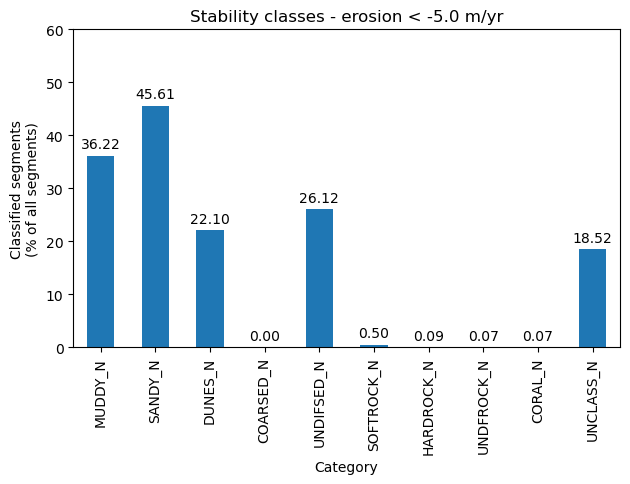

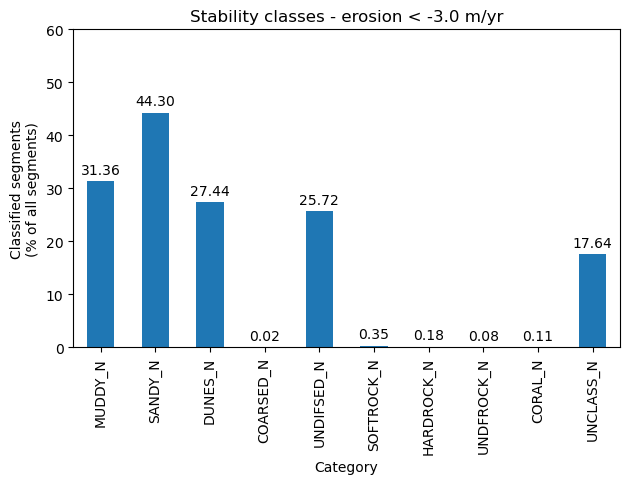

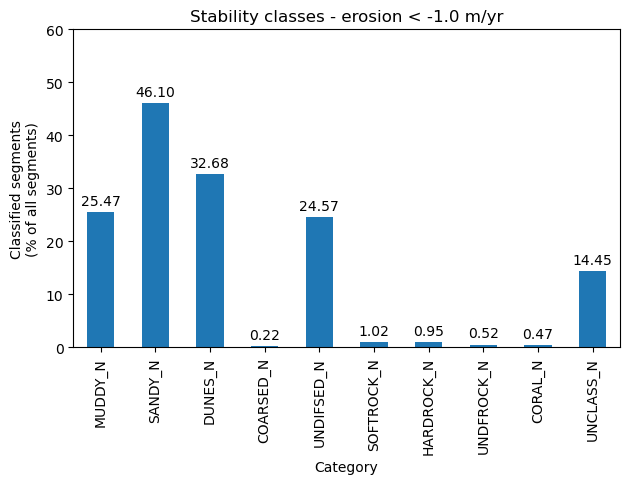

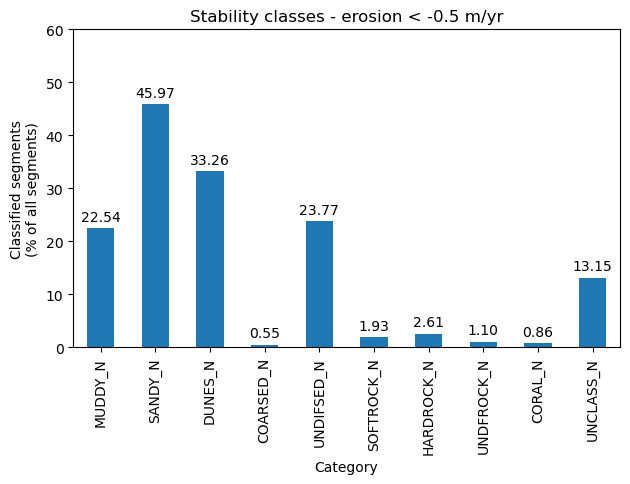

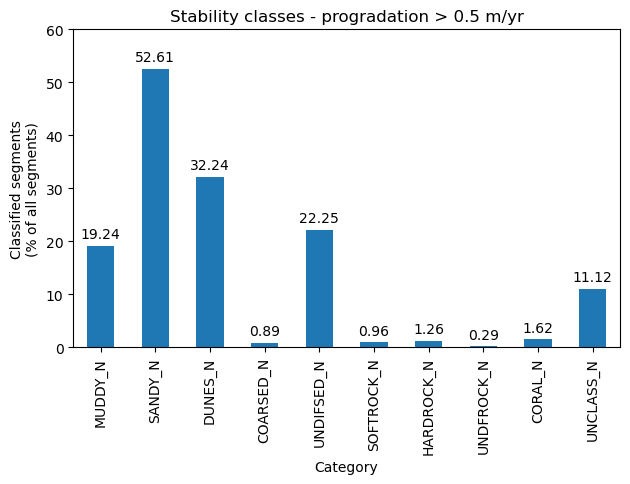

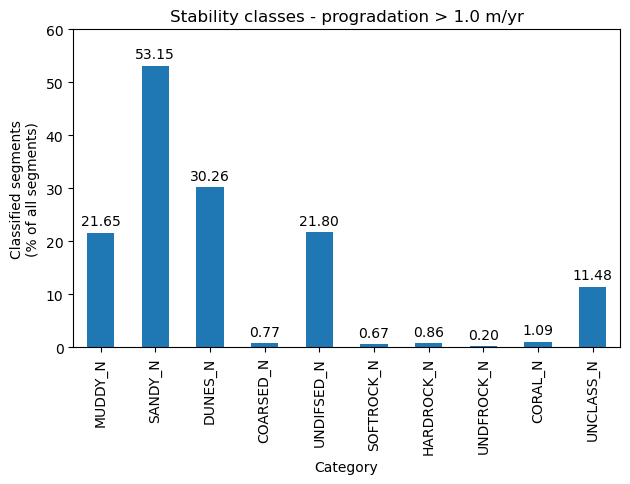

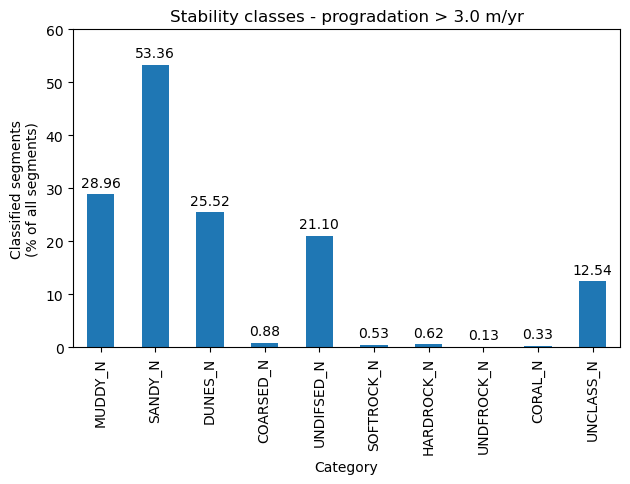

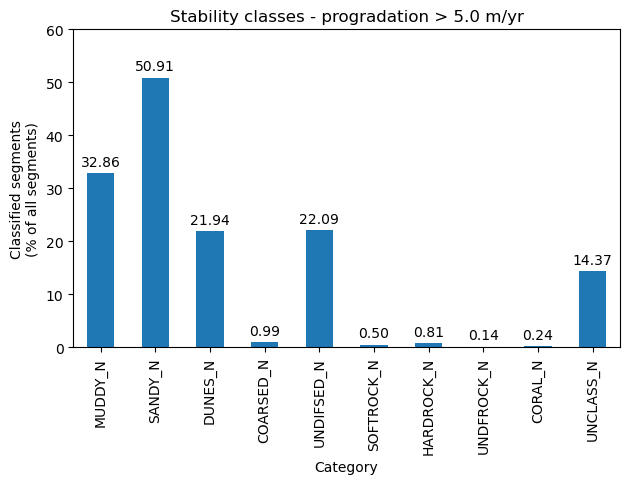

In [16]:
smartline = smartline.to_crs("EPSG:3577")

# Rates to set erosion and progradation from DEACL rates of change
deacl_change_rates = [-5.0, -3.0, -1.0, -0.5, 0.5, 1.0, 3.0, 5.0]

for rate in deacl_change_rates:
    # print (f'rate: {rate}')
    # Which landform stability classes (Smartline) are associated with erosional/progradation coastlines (DEACL)?
    if rate < 0:
        changing_DEACL = ratesofchange_gdf[ratesofchange_gdf['rate_time'] < rate]
    else:
        changing_DEACL = ratesofchange_gdf[ratesofchange_gdf['rate_time'] > rate]
    # print (f'changing_DEACL: {changing_DEACL.head(2)}')    
    
    # Identify smartline segments closest to changing DEACL points
    deacl_smartline = gpd.sjoin_nearest(
        changing_DEACL,
        smartline,
        how='left',
        distance_col='dist_to_point'
    )
    # Drop duplicates where the smartline segment is equidistant from the DEACL point, keeping the first match only
    deacl_smartline = deacl_smartline[~deacl_smartline.index.duplicated(keep='first')]
    # print (f'deacl_smartline: {deacl_smartline.head(2)}')
    
    # List to store data for plotting
    stability = [] 
    # Prepare data. Count values per stability class
    for name in landform_stability:
        count = deacl_smartline[name[0]].where(deacl_smartline[name[0]]!='000').count()
        count=count/len(deacl_smartline)*100
        stability.append([name[0], count])
    # Plot
    labels = list(x[0] for x in stability)
    values = list(x[1] for x in stability)
    
    ax = pd.Series(values, index=labels).plot(kind='bar')
    ax.bar_label(ax.containers[0], fmt='%.2f', padding=3) 
    
    plt.xlabel('Category')
    plt.ylim(0,60)
    plt.ylabel('Classified segments\n(% of all segments)')
    plt.tight_layout()
    if rate < 0:
        plt.title(f'Stability classes - erosion < {rate} m/yr')
        plt.savefig(f'Stability_classes_national_erosion_less_than_{str(rate).replace(".", "-")}.png', bbox_inches='tight')
    else:
        plt.title(f'Stability classes - progradation > {rate} m/yr')
        plt.savefig(f'Stability_classes_national_progradation_more_than_{str(rate).replace(".", "-")}.png', bbox_inches='tight')
     

    
    plt.show()
    plt.close()

In [ ]:
smartline.columns

In [8]:
# count number of unclassified classes in Smartline (national summary)
state_names = ['wa','nt','sa','tas','vic','nsw','qld']

# Rates to set erosion and progradation from DEACL rates of change

deacl_change_rates = [-5.0, -3.0, -1.0, -0.5, 0.5, 1.0, 3.0, 5.0]

# Separate smartline segments per state polygon
matched_list = []

for idx, row in state_coast_boundaries.iterrows():
    polygon = row.geometry
    subset = smartline[smartline.within(polygon)].copy()
    subset['state_name'] = row['name'] 
    matched_list.append(subset)

points_within = pd.concat(matched_list, ignore_index=True)
points_within = gpd.GeoDataFrame(points_within, crs=smartline.crs)

# Set study area
study_area = state_coast_boundaries.set_index("name")
study_area = study_area.to_crs("EPSG:3577")

# stability = [] 

In [ ]:
for state in state_names[0:1]:
    print (f'state: {state}')

    # Load data from WFS per state bbox in the study area
    bbox = np.array(study_area.loc[state].geometry.bounds)
    ratesofchange_gdf = get_coastlines(
        bbox=bbox, layer="rates_of_change"
    )
    # Clip returned data to polygon extent
    ratesofchange_gdf = gpd.clip(ratesofchange_gdf, mask=study_area.loc[state].geometry)
    print (f'ratesofchange_gdf: {ratesofchange_gdf.head(2)}')
    
    # Select smartline points per state
    points = (points_within[points_within['state_name'] == state]).to_crs("EPSG:3577")
    print (f'points: {points.head(2)}')
    
    for rate in deacl_change_rates[0:1]:
        print (f'rate: {rate}')
        # Which landform stability classes (Smartline) are associated with erosional/progradation coastlines (DEACL)?
        if rate < 0:
            changing_DEACL = ratesofchange_gdf[ratesofchange_gdf['rate_time'] < rate]
        else:
            changing_DEACL = ratesofchange_gdf[ratesofchange_gdf['rate_time'] > rate]
        print (f'changing_DEACL: {changing_DEACL.head(2)}')    
        
        # Identify smartline segments closest to changing DEACL points
        deacl_smartline = gpd.sjoin_nearest(
            changing_DEACL,
            points,
            how='left',
            distance_col='dist_to_point'
        )
        # Drop duplicates where the smartline segment is equidistant from the DEACL point, keeping the first match only
        deacl_smartline = deacl_smartline[~deacl_smartline.index.duplicated(keep='first')]
        print (f'deacl_smartline: {deacl_smartline.head(2)}')
        
        # # List to store data for plotting
        # stability = [] 
        # # Prepare data. Count values per stability class
        # for name in landform_stability:
        #     count = deacl_smartline[name[0]].where(deacl_smartline[name[0]]!='000').count()
        #     count=count/len(deacl_smartline)*100
        #     stability.append([name[0], count])
        # # Plot
        # labels = list(x[0] for x in stability)
        # values = list(x[1] for x in stability)
        
        # pd.Series(values, index=labels).plot(kind='bar')
        # plt.xlabel('Category')
        # plt.ylim(0,110)
        # plt.ylabel('Classified segments\n(% of all segments)')
        # if rate < 0:
        #     plt.title(f'Stability classes - {state.upper()} erosion < {rate} m/yr')
        #     plt.savefig(f'Stability_classes_{state.upper()}_erosion_less_than_{str(rate).replace(".", "-")}.png')
        # else:
        #     plt.title(f'Stability classes - {state.upper()} progradation > {rate} m/yr')
        #     plt.savefig(f'Stability_classes_{state.upper()}_progradation_more_than_{str(rate).replace(".", "-")}.png')
         
        # plt.tight_layout()
        
        # plt.show()
        # plt.close()

In [ ]:
for name in landform_stability:
    print (f'{name[0]}: {smartline[name[0]].unique()}')

In [ ]:
# Load data from WFS per state bbox in the study area
bbox = study_area.geometry.bounds.values[0]

ratesofchange_gdf = get_coastlines(
    bbox=bbox, layer="rates_of_change"
)
# Clip returned data to polygon extent
ratesofchange_gdf = gpd.clip(ratesofchange_gdf, mask=study_area)
print (f'ratesofchange_gdf: {ratesofchange_gdf.head(2)}')

In [ ]:
# ?study_area.geometry.bounds.values[0]

In [ ]:
# study_area.loc['wa'].geometry.bounds.as_array

In [ ]:
# Load data from WFS per state bbox in the study area
bbox = study_area.geometry.bounds.values[0]

ratesofchange_gdf = get_coastlines(
    bbox=bbox, layer="rates_of_change"
)
# Clip returned data to polygon extent
# ratesofchange_gdf = gpd.clip(ratesofchange_gdf, mask=study_area.loc[state].geometry)
ratesofchange_gdf = gpd.clip(ratesofchange_gdf, mask=study_area)
print (f'ratesofchange_gdf: {ratesofchange_gdf.head(2)}')